In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
%reload_ext autoreload

In [2]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [ ]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

In [3]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

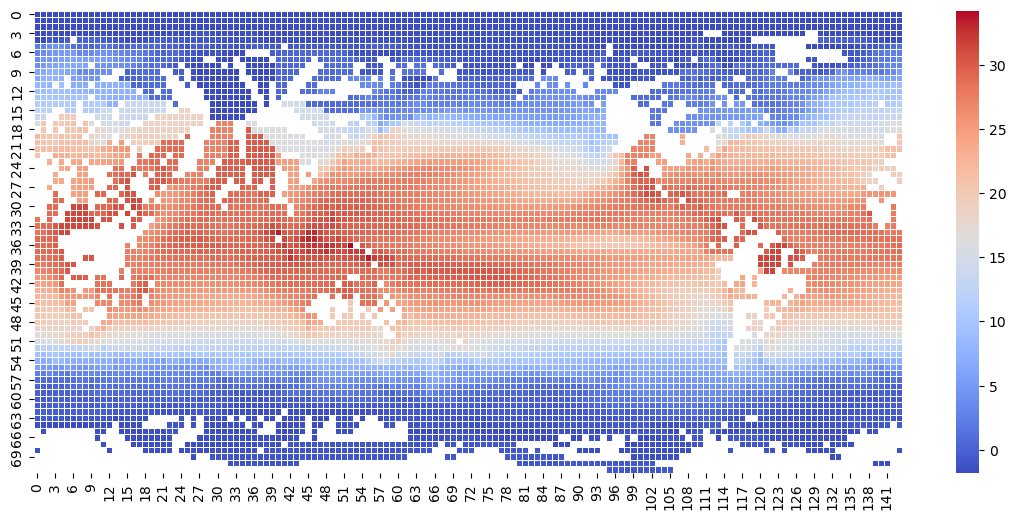

In [4]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

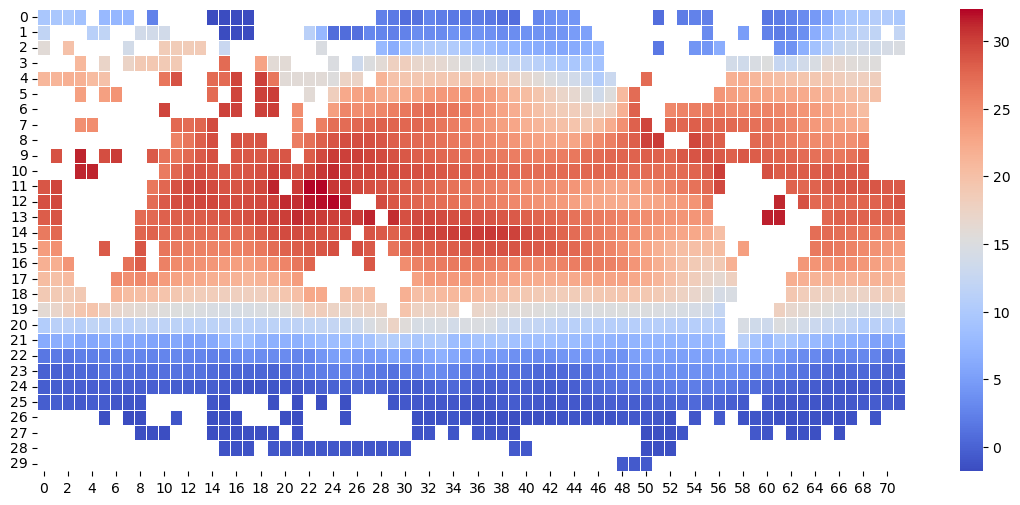

In [5]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

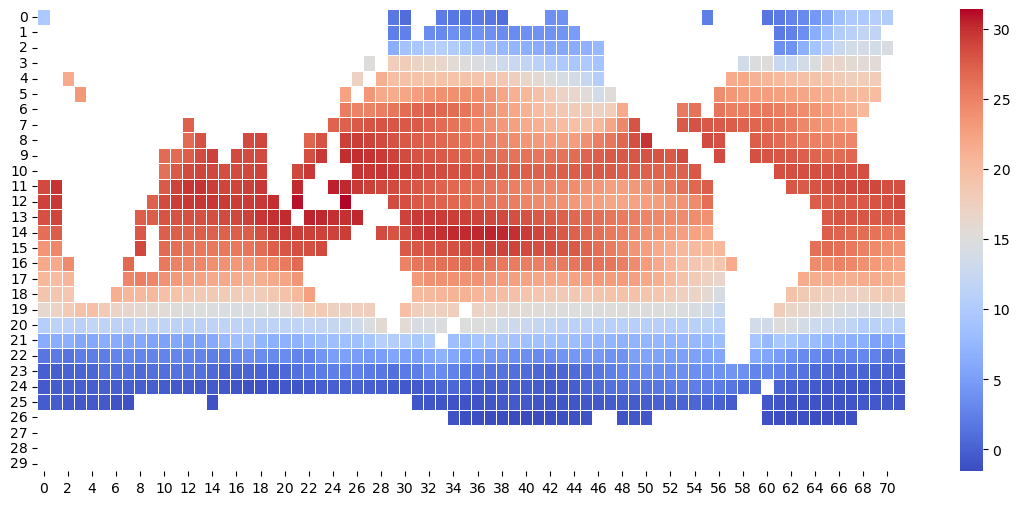

In [6]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [7]:
def extract_per_timeserie(cope_data, mask, r=[-10, 10]):
    X, Y = [], []
    for model in cope_data.keys():
        normalized_grids, mean_forced_response, _, _ = normalize_flatten_model(cope_data, model, mask)
        flattened_mean_forced_response = mean_forced_response.flatten()
        for run, grid_timeserie in normalized_grids.items():
            flattened_grid_timeserie = grid_timeserie.flatten()
            
            if (r[0] < flattened_grid_timeserie.min() and flattened_grid_timeserie.max() < r[1]):
                X.append(flattened_grid_timeserie)
                Y.append(flattened_mean_forced_response)

    X, Y = np.array(X), np.array(Y)
    return X, Y


In [8]:
X, Y = extract_per_timeserie(cope_data, union_nan_mask, r=[-10, 10])

X.shape

(671, 44472)

In [9]:
Y.shape

(671, 44472)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [11]:
batch_size = 16

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [12]:
lr = 2e-3
epochs = 30

model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training basic VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training basic VAE...
Epoch 1 complete ! 	Average Loss:  651079.4839311079
Epoch 2 complete ! 	Average Loss:  10457.421564275568
Epoch 3 complete ! 	Average Loss:  9399.67616595644
Epoch 4 complete ! 	Average Loss:  8665.444557883522
Epoch 5 complete ! 	Average Loss:  8405.162560665247
Epoch 6 complete ! 	Average Loss:  8263.899569424715
Epoch 7 complete ! 	Average Loss:  8146.199662642045
Epoch 8 complete ! 	Average Loss:  8276.578835227272
Epoch 9 complete ! 	Average Loss:  8035.678858901515
Epoch 10 complete ! 	Average Loss:  7969.940000591856
Epoch 11 complete ! 	Average Loss:  7927.364657315341
Epoch 12 complete ! 	Average Loss:  7919.544063683712
Epoch 13 complete ! 	Average Loss:  8557.808578953598
Epoch 14 complete ! 	Average Loss:  7976.912982362689
Epoch 15 complete ! 	Average Loss:  7755.454804391572
Epoch 16 complete ! 	Average Loss:  7654.18339399858
Epoch 17 complete ! 	Average Loss:  7646.499955610795
Epoch 18 complete ! 	Average Loss:  7546.279430042614
Epoch 19 c

In [13]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)

        break

In [14]:
x.shape

torch.Size([16, 44472])

In [ ]:
index = 1
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
index = 25
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
index = 3
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
index = 4
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
index = 5
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
lr = 1e-3
epochs = 20

model = VAE(input_dim=1308, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

In [15]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

In [16]:
x.shape

torch.Size([16, 44472])

C:\Users\mirco\AppData\Local\Temp\ipykernel_17496\3800019002.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_animated_timeserie(np.array(x[0]), union_nan_mask)


4.318645 -4.2599893


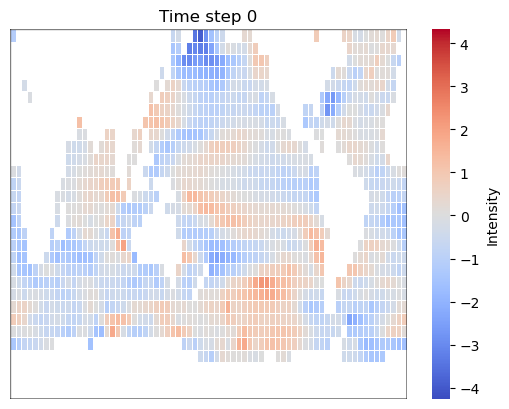

In [17]:
from plots import get_animated_timeserie

a = get_animated_timeserie(np.array(x[0]), union_nan_mask)
a.save('test_solo.gif', writer='pillow', fps=1)

C:\Users\mirco\AppData\Local\Temp\ipykernel_17496\1712822756.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  a = get_duo_animated_timeserie(np.array(x[0]), np.array(x_hat[0]), union_nan_mask)


4.318645 -4.2599893


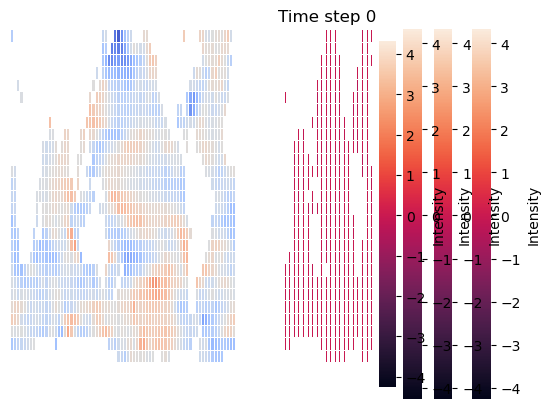

In [36]:
from plots import get_duo_animated_timeserie

a = get_duo_animated_timeserie(np.array(x[0]), np.array(x_hat[0]), union_nan_mask)
a.save('test_duo.gif', writer='pillow', fps=1)

In [ ]:
index = 12
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [43]:
import os
os.environ['PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT']='2'

In [ ]:
from plots import plot_trio_grids

index = 12
plot_trio_grids(x=x[index], x_hat=x_hat[index], y=y[index], union_nan_mask=union_nan_mask)

In [ ]:
min((x[index].ravel().min(), x_hat[index].ravel().min()))

In [ ]:
x[index].ravel().max()